### Loading the dataset

In [34]:
import pandas as pd
import numpy as np

data = pd.read_csv("hacker_news_posts.csv")
data.head(5)

,post_id,title,post_by,age,points,comment_count
0,44281727,Datalog in Rust,brson,2 hours ago,77,7
1,44282017,How to modify Starlink Mini to run without the...,LorenDB,1 hour ago,35,7
2,44281958,Show HN: Meow – An Image File Format I made be...,kuberwastaken,1 hour ago,28,12
3,44282177,Canyon.mid,LorenDB,40 minutes ago,5,1
4,44257422,1k year old 3 sisters crop farm found in North...,CoopaTroopa,3 hours ago,19,1


### 1. Check some basic information for the dataset

In [2]:
print(f"Shape of the DataFrame: {data.shape}\n")

Shape of the DataFrame: (744, 6)



In [3]:
print(f"Data info:\n{data.info()}\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   post_id        744 non-null    int64 
 1   title          744 non-null    object
 2   post_by        743 non-null    object
 3   age            744 non-null    object
 4   points         744 non-null    int64 
 5   comment_count  744 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 35.0+ KB
Data info:
None



In [4]:
print(f"Data types:\n{data.dtypes}\n")

Data types:
post_id           int64
title            object
post_by          object
age              object
points            int64
comment_count     int64
dtype: object



In [5]:
print(f"Missing values:\n{data.isnull().sum()}\n")

Missing values:
post_id          0
title            0
post_by          1
age              0
points           0
comment_count    0
dtype: int64



In [6]:
print(f"Duplicate rows: {data.duplicated().sum()}\n")

Duplicate rows: 0



In [7]:
print(f"\nBasic statistics:\n{data.describe()}")


Basic statistics:
            post_id       points  comment_count
count  7.440000e+02   744.000000     744.000000
mean   4.424946e+07   101.606183      55.852151
std    2.153625e+04   181.278106     124.082461
min    4.421141e+07     0.000000       0.000000
25%    4.423075e+07    11.000000       1.000000
50%    4.425023e+07    31.500000       9.000000
75%    4.427029e+07   116.250000      54.250000
max    4.428218e+07  2415.000000    1672.000000


In [8]:
data.head(5)

,post_id,title,post_by,age,points,comment_count
0,44281727,Datalog in Rust,brson,2 hours ago,77,7
1,44282017,How to modify Starlink Mini to run without the...,LorenDB,1 hour ago,35,7
2,44281958,Show HN: Meow – An Image File Format I made be...,kuberwastaken,1 hour ago,28,12
3,44282177,Canyon.mid,LorenDB,40 minutes ago,5,1
4,44257422,1k year old 3 sisters crop farm found in North...,CoopaTroopa,3 hours ago,19,1


### 2. Data Cleaning

#### 2.1 Remove rows with missing values

In [35]:
data = data.dropna(subset='post_by')
data.isnull().sum()

post_id          0
title            0
post_by          0
age              0
points           0
comment_count    0
dtype: int64

#### 2.2 Create function to convert age to numeric

In [36]:
def clean_age(age_str):
    if pd.isnull(age_str):
        return np.nan
    
    age_str = age_str.lower().strip()
    
    # Extract number
    number = ""
    for char in age_str:
        if char.isdigit():
            number += char
        elif number:
            break
    
    if not number:
        return np.nan
    
    num = int(number)
    
    # Convert to hours based on unit
    if 'minute' in age_str:
        return round(num / 60, 2)  # Convert minutes to hours
    elif 'hour' in age_str:
        return num  # Already in hours
    elif 'day' in age_str:
        return num * 24  # Convert days to hours
    else:
        return num  # Default assume hours

data['age'] = data['age'].apply(clean_age)

### 3. Feature Engineering

#### 3.1 Create a new column with the length of the title

**Why do we create this?**
- Long titles might be harder to read
- Short titles might be more catchy 
- We want to see if title length affects how popular a post becomes
- This helps us understand if people prefer short or long titles

In [37]:
data['title_length'] = data['title'].str.len()
data['title_length']

0      15
1      67
2      78
3      10
4      58
       ..
739    70
740    62
741    37
742    40
743    46
Name: title_length, Length: 743, dtype: int64

#### 3.2 Create binary feature for comments

**Why do we create this?**
- We want to know: "Does this post have any comments or not?"
- Posts with comments show that people are interested
- This is a simple yes/no question (1 = has comments, 0 = no comments)
- It's easier for our model to understand than counting exact number of comments

In [38]:
data['has_comments'] = (data['comment_count'] > 0).astype(int)
data['has_comments'].value_counts()

has_comments
1    609
0    134
Name: count, dtype: int64

In [42]:
data['comment_count'].quantile(0.8)

76.60000000000002

#### 3.3 Create high_comments and high_points targets

In [39]:
data['high_comments'] = (data['comment_count'] > data['comment_count'].quantile(0.8)).astype(int)
data['high_points'] = (data['points'] > data['points'].quantile(0.8)).astype(int)

**What are we creating?**
- **`high_comments`**: Posts with lots of comments (top 20%)
- **`high_points`**: Posts with lots of upvotes (top 20%)

**Why create these?**
We want to identify what makes posts successful. Instead of looking at all posts together, we separate them into:
- Posts that get people talking (high comments)
- Posts that get lots of likes (high points)

This helps us understand different types of success on the platform.

In [40]:
data['high_comments'].value_counts(), data['high_points'].value_counts()

(high_comments
 0    594
 1    149
 Name: count, dtype: int64,
 high_points
 0    594
 1    149
 Name: count, dtype: int64)

### 4. Data Visualization

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

#### 4.1 Basic Distributions

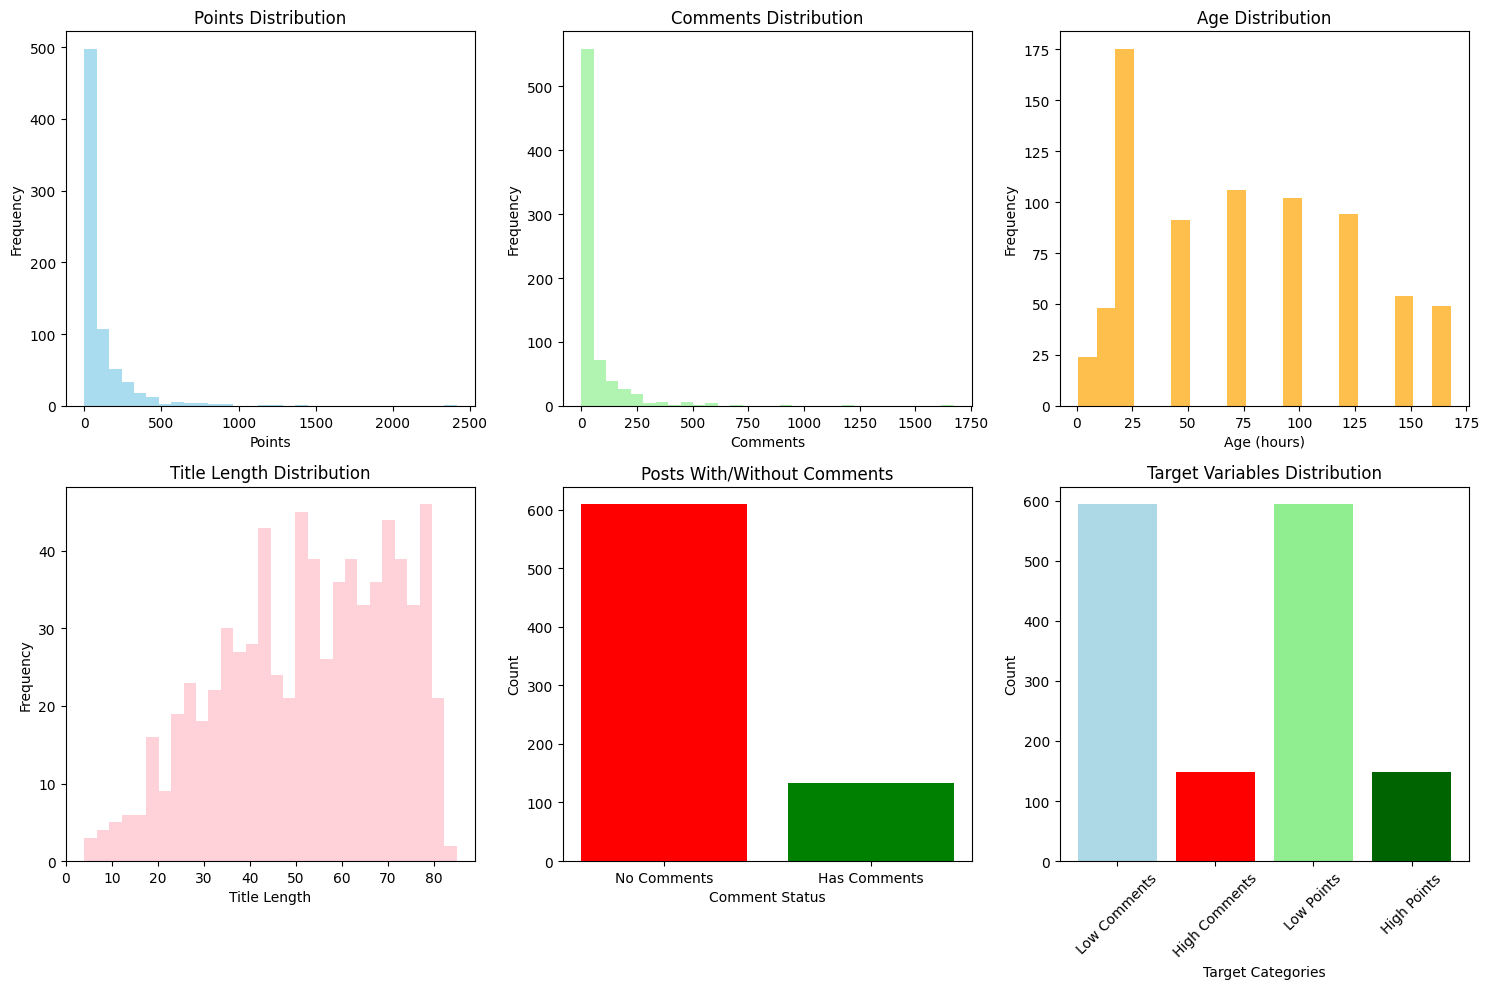

In [56]:
plt.figure(figsize=(15, 10))

# Top row - Main features used in models
plt.subplot(2, 3, 1)
plt.hist(data['points'], bins=30, alpha=0.7, color='skyblue')
plt.xlabel('Points')
plt.ylabel('Frequency')
plt.title('Points Distribution')

plt.subplot(2, 3, 2)
plt.hist(data['comment_count'], bins=30, alpha=0.7, color='lightgreen')
plt.xlabel('Comments')
plt.ylabel('Frequency')
plt.title('Comments Distribution')

plt.subplot(2, 3, 3)
plt.hist(data['age'], bins=20, alpha=0.7, color='orange')
plt.xlabel('Age (hours)')
plt.ylabel('Frequency')
plt.title('Age Distribution')

# Bottom row - Engineered features
plt.subplot(2, 3, 4)
plt.hist(data['title_length'], bins=30, alpha=0.7, color='pink')
plt.xlabel('Title Length')
plt.ylabel('Frequency')
plt.title('Title Length Distribution')

plt.subplot(2, 3, 5)
comments_counts = data['has_comments'].value_counts()
plt.bar(['No Comments', 'Has Comments'], comments_counts.values, color=['red', 'green'])
plt.xlabel('Comment Status')
plt.ylabel('Count')
plt.title('Posts With/Without Comments')

plt.subplot(2, 3, 6)
high_comments_counts = data['high_comments'].value_counts()
high_points_counts = data['high_points'].value_counts()
x = ['Low Comments', 'High Comments', 'Low Points', 'High Points']
y = [high_comments_counts[0], high_comments_counts[1], high_points_counts[0], high_points_counts[1]]
colors = ['lightblue', 'red', 'lightgreen', 'darkgreen']
plt.bar(x, y, color=colors)
plt.xlabel('Target Categories')
plt.ylabel('Count')
plt.title('Target Variables Distribution')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- **Points chart**: Most posts get 0-500 points, very few get 1000+ points
- **Comments chart**: Most posts get 0-50 comments, some get way more  
- **Age chart**: Most posts are new (0-10 hours old)
- **Title Length**: People usually write titles that are 40-80 characters long
- **Has Comments**: Almost all posts get at least 1 comment (green bar is much bigger)
- **Our Targets**: We split posts into "high" and "low" groups - 80% are low, 20% are high

**Why this matters**: These patterns help us understand what "normal" vs "successful" posts look like.

#### 4.2 Correlations Analysis

C:\Windows\Temp\ipykernel_13988\3916172721.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_chane = data.groupby(age_bins).agg({


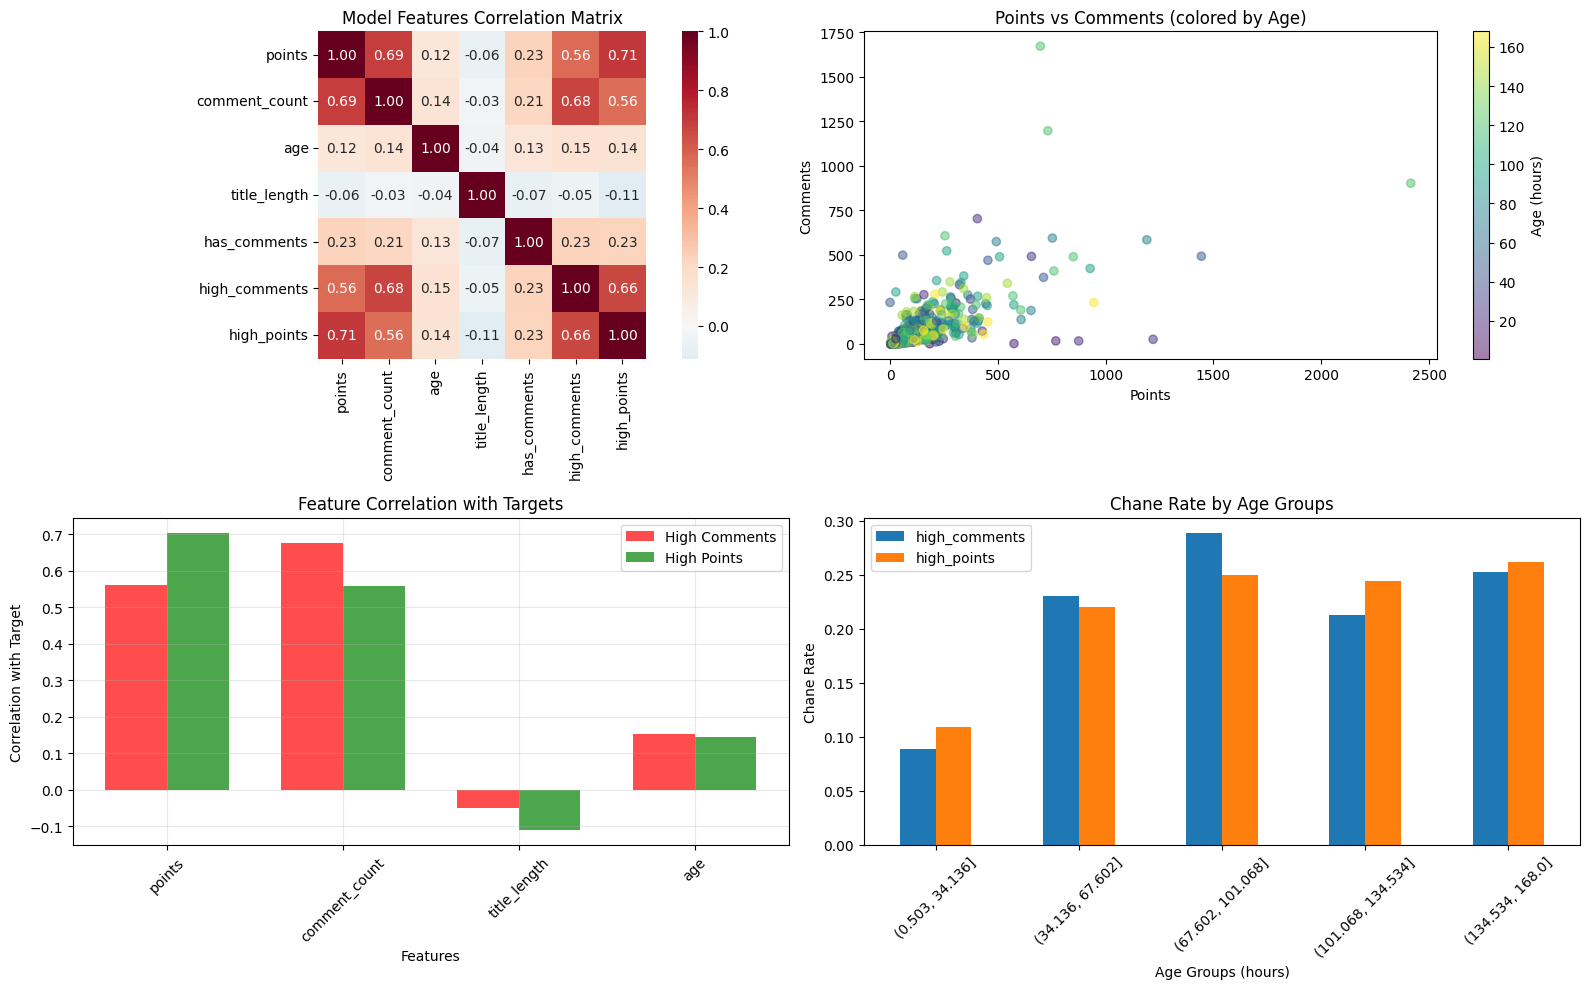

In [59]:
plt.figure(figsize=(16, 10))

# Correlation heatmap for model features only
plt.subplot(2, 2, 1)
model_features = ['points', 'comment_count', 'age', 'title_length', 'has_comments', 'high_comments', 'high_points']
corr_matrix = data[model_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, square=True, fmt='.2f')
plt.title('Model Features Correlation Matrix')

# Points vs Comments relationship
plt.subplot(2, 2, 2)
plt.scatter(data['points'], data['comment_count'], alpha=0.5, c=data['age'], cmap='viridis')
plt.colorbar(label='Age (hours)')
plt.xlabel('Points')
plt.ylabel('Comments')
plt.title('Points vs Comments (colored by Age)')

# Feature relationships with targets
plt.subplot(2, 2, 3)
target_corr_high_comments = data[['points', 'comment_count', 'title_length', 'age']].corrwith(data['high_comments'])
target_corr_high_points = data[['points', 'comment_count', 'title_length', 'age']].corrwith(data['high_points'])

x = np.arange(len(target_corr_high_comments))
width = 0.35
plt.bar(x - width/2, target_corr_high_comments.values, width, label='High Comments', color='red', alpha=0.7)
plt.bar(x + width/2, target_corr_high_points.values, width, label='High Points', color='green', alpha=0.7)
plt.xlabel('Features')
plt.ylabel('Correlation with Target')
plt.title('Feature Correlation with Targets')
plt.xticks(x, target_corr_high_comments.index, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# Age vs target success rate
plt.subplot(2, 2, 4)
age_bins = pd.cut(data['age'], bins=5)
age_chane = data.groupby(age_bins).agg({
    'high_comments': 'mean',
    'high_points': 'mean',
})
age_chane.plot(kind='bar', ax=plt.gca())
plt.title('Chane Rate by Age Groups')
plt.xlabel('Age Groups (hours)')
plt.ylabel('Chane Rate')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

C:\Windows\Temp\ipykernel_13988\2797940072.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_success = data.groupby(age_bins).agg({


,high_comments,high_points
age,,
"(0.503, 34.136]",0.089069,0.109312
"(34.136, 67.602]",0.230769,0.219780
"(67.602, 101.068]",0.288462,0.250000
"(101.068, 134.534]",0.212766,0.244681
"(134.534, 168.0]",0.252427,0.262136


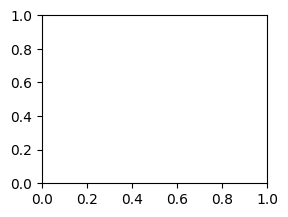

In [44]:
plt.subplot(2, 2, 4)
age_bins = pd.cut(data['age'], bins=5)
age_success = data.groupby(age_bins).agg({
    'high_comments': 'mean',
    'high_points': 'mean'
})

age_success

**Chart 1 (Colored Grid)**: Shows which features are related
- Dark red = strongly connected
- Dark blue = not connected  
- Points and comments are connected (0.69) - posts with more points usually get more comments

**Chart 2 (Scatter Plot)**: Each dot is a post
- Posts in top-right corner have lots of points AND comments
- Dark dots are newer posts, yellow dots are older posts

**Chart 3 (Bar Chart)**: Shows which features help predict our targets
- For predicting high comments: points work best
- For predicting high points: comments work best

**Chart 4 (Age Groups)**: Shows that medium-age posts do better than very new or very old posts

**What this means**: We can use points to predict comments, and comments to predict points!

#### 4.3 Feature Relations

C:\Windows\Temp\ipykernel_13988\1246368001.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_impact = data.groupby(age_groups).agg({


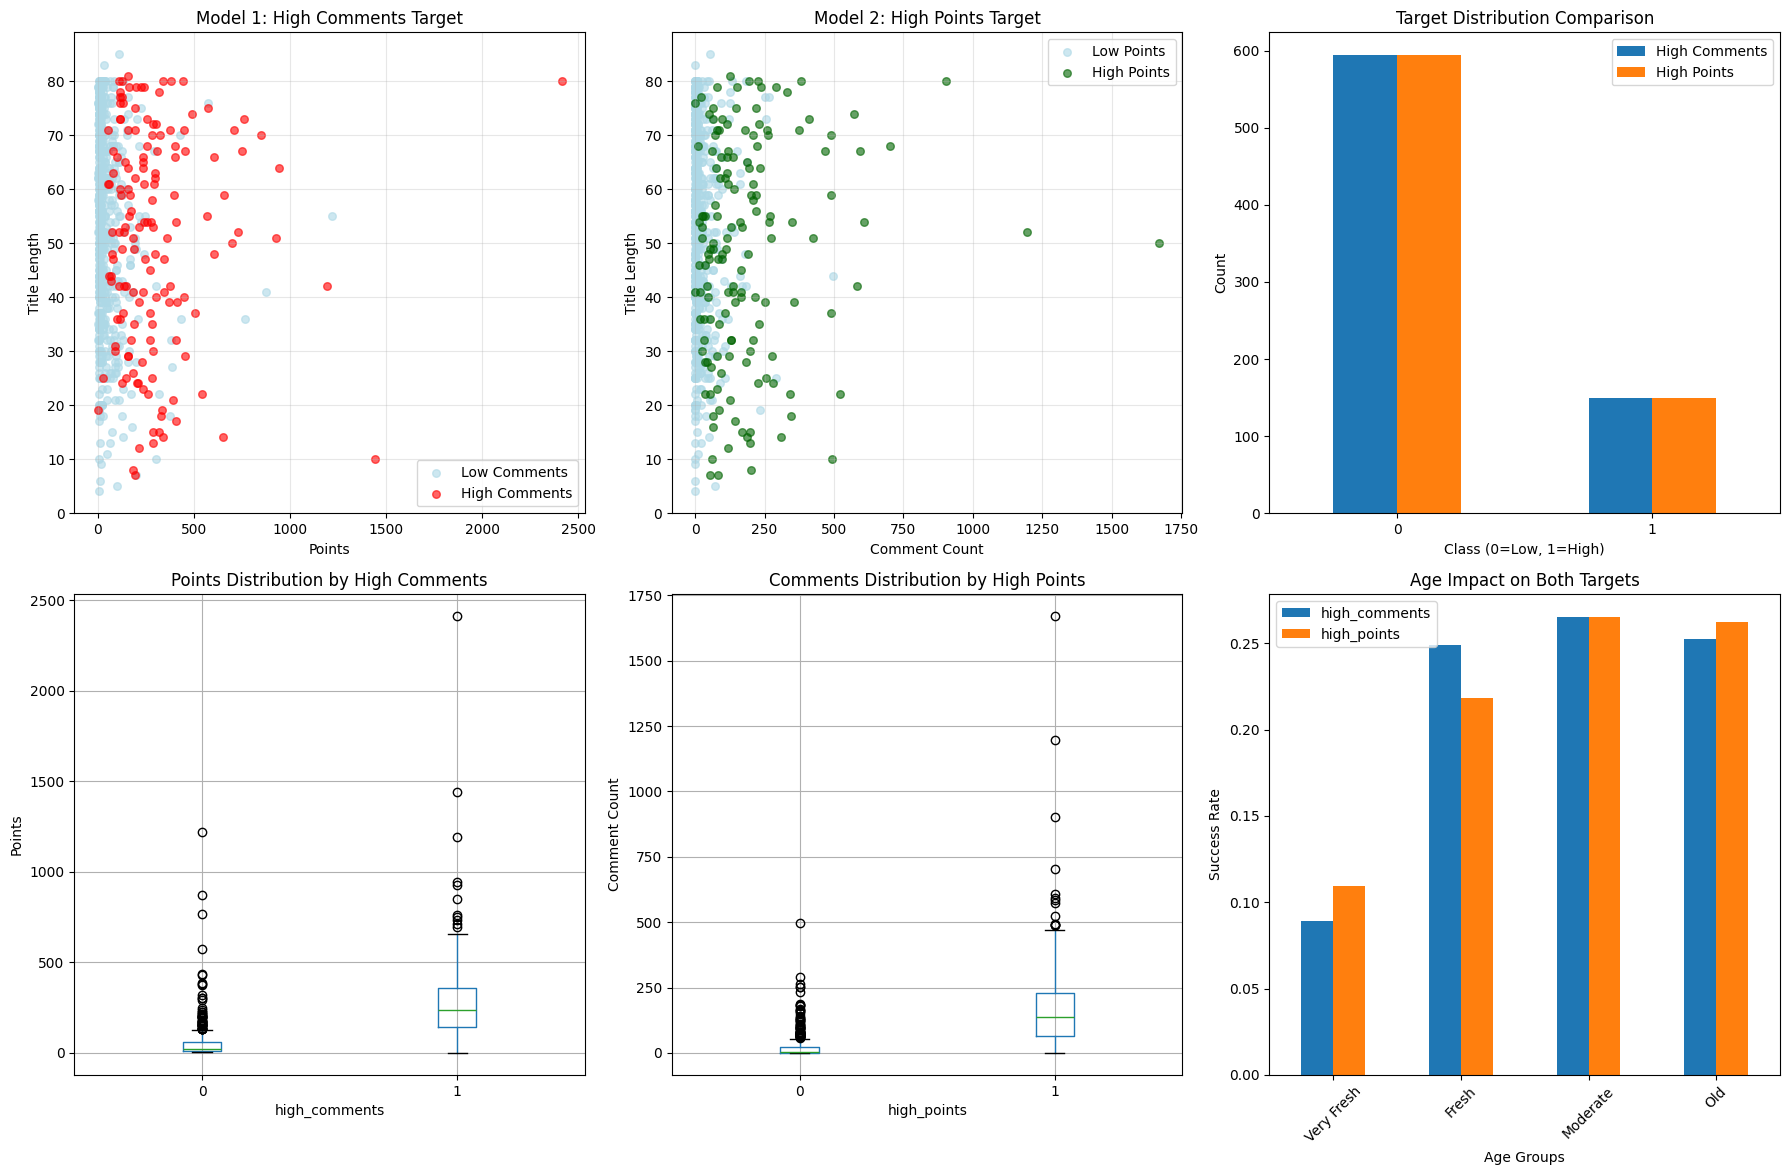

In [61]:
plt.figure(figsize=(18, 12))

# Model 1 target analysis
plt.subplot(2, 3, 1)
low_comments = data[data['high_comments'] == 0]
high_comments = data[data['high_comments'] == 1]
plt.scatter(low_comments['points'], low_comments['title_length'], alpha=0.6, label='Low Comments', color='lightblue', s=30)
plt.scatter(high_comments['points'], high_comments['title_length'], alpha=0.6, label='High Comments', color='red', s=30)
plt.xlabel('Points')
plt.ylabel('Title Length')
plt.title('Model 1: High Comments Target')
plt.legend()
plt.grid(True, alpha=0.3)

# Model 2 target analysis
plt.subplot(2, 3, 2)
low_points = data[data['high_points'] == 0]
high_points = data[data['high_points'] == 1]
plt.scatter(low_points['comment_count'], low_points['title_length'], alpha=0.6, label='Low Points', color='lightblue', s=30)
plt.scatter(high_points['comment_count'], high_points['title_length'], alpha=0.6, label='High Points', color='darkgreen', s=30)
plt.xlabel('Comment Count')
plt.ylabel('Title Length')
plt.title('Model 2: High Points Target')
plt.legend()
plt.grid(True, alpha=0.3)

# Target distribution analysis
plt.subplot(2, 3, 3)
target_comparison = pd.DataFrame({
    'High Comments': data['high_comments'].value_counts(),
    'High Points': data['high_points'].value_counts()
})
target_comparison.plot(kind='bar', ax=plt.gca())
plt.title('Target Distribution Comparison')
plt.xlabel('Class (0=Low, 1=High)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()

# Feature separation analysis - Model 1
plt.subplot(2, 3, 4)
data.boxplot(column='points', by='high_comments', ax=plt.gca())
plt.title('Points Distribution by High Comments')
plt.suptitle('')
plt.ylabel('Points')

# Feature separation analysis - Model 2
plt.subplot(2, 3, 5)
data.boxplot(column='comment_count', by='high_points', ax=plt.gca())
plt.title('Comments Distribution by High Points')
plt.suptitle('')
plt.ylabel('Comment Count')

# Age impact on both targets
plt.subplot(2, 3, 6)
age_groups = pd.cut(data['age'], bins=4, labels=['Very Fresh', 'Fresh', 'Moderate', 'Old'])
age_impact = data.groupby(age_groups).agg({
    'high_comments': 'mean',
    'high_points': 'mean'
})
age_impact.plot(kind='bar', ax=plt.gca())
plt.title('Age Impact on Both Targets')
plt.xlabel('Age Groups')
plt.ylabel('Success Rate')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

**Charts 1 & 2**: Each dot is a post, colors show if it's successful or not
- Red dots = high success posts
- Blue dots = low success posts  
- We can see the successful posts are in different areas - this means our models can learn to separate them!

**Chart 3**: Shows our targets have the same split (80% low, 20% high) - this is fair for both models

**Charts 4 & 5**: Box plots show the difference between successful and not successful posts
- High-comment posts have way more points
- High-point posts have way more comments
- Almost no overlap = easy for models to learn!

**Chart 6**: Shows that "fresh" and "moderate" age posts do best

**Bottom line**: These patterns are so clear that our models should work really well!

### 5. Build Machine Learning Model

#### 5.1 Model 1: Popular vs Not Popular (Logistic Regression)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X1 = data[['points', 'title_length', 'age']]
y1 = data['high_comments']
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

model1 = LogisticRegression(class_weight='balanced', random_state=42)
model1.fit(X_train1, y_train1)
y_pred1 = model1.predict(X_test1)
accuracy1 = accuracy_score(y_test1, y_pred1)

In [20]:
from sklearn.metrics import classification_report, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix

print("MODEL 1:")
print(f"Accuracy: {accuracy1:.3f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test1, y_pred1))

# Calculate additional metrics
cm1 = confusion_matrix(y_test1, y_pred1)
tn, fp, fn, tp = cm1.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

print(f"\nAdditional Metrics:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")
print(f"Specificity (True Negative Rate): {specificity:.3f}")
print(f"Sensitivity (True Positive Rate): {sensitivity:.3f}")

MODEL 1:
Accuracy: 0.886

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.89      0.93       123
           1       0.62      0.88      0.73        26

    accuracy                           0.89       149
   macro avg       0.80      0.89      0.83       149
weighted avg       0.91      0.89      0.89       149


Additional Metrics:
True Negatives: 109
False Positives: 14
False Negatives: 3
True Positives: 23
Specificity (True Negative Rate): 0.886
Sensitivity (True Positive Rate): 0.885


##### Decision Boundary

3-Feature Model Coefficients:
Points: 0.0184
Title Length: 0.0041
Age: 0.0028
Intercept: -2.6467


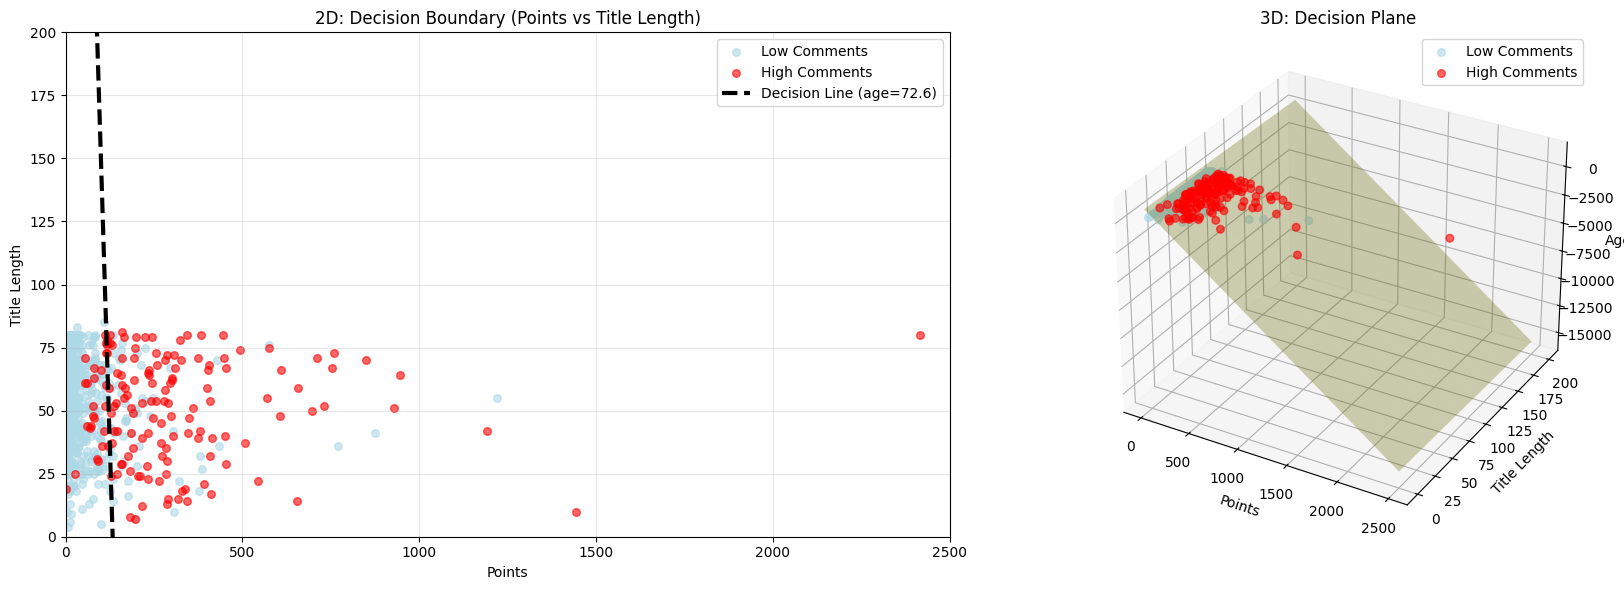

In [21]:
coef = model1.coef_[0] 
intercept = model1.intercept_[0]

print(f"3-Feature Model Coefficients:")
print(f"Points: {coef[0]:.4f}")
print(f"Title Length: {coef[1]:.4f}") 
print(f"Age: {coef[2]:.4f}")
print(f"Intercept: {intercept:.4f}")

plt.figure(figsize=(18, 6))

# Create data splits for visualization
low_comments_posts = data[data['high_comments'] == 0]
high_comments_posts = data[data['high_comments'] == 1]

# 2D Plot (Points vs Title Length)
plt.subplot(1, 2, 1)
plt.scatter(low_comments_posts['points'], low_comments_posts['title_length'], 
           color='lightblue', alpha=0.6, label='Low Comments', s=30)
plt.scatter(high_comments_posts['points'], high_comments_posts['title_length'], 
           color='red', alpha=0.6, label='High Comments', s=30)

# Decision line for average age
avg_age = data['age'].mean()
x_line = np.linspace(0, 2500, 100)
y_line = -(coef[0] * x_line + coef[2] * avg_age + intercept) / coef[1]
plt.plot(x_line, y_line, 'k--', linewidth=3, label=f'Decision Line (age={avg_age:.1f})')

plt.xlabel('Points')
plt.ylabel('Title Length')
plt.title('2D: Decision Boundary (Points vs Title Length)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 2500)
plt.ylim(0, 200)

# 3D Plot
from mpl_toolkits.mplot3d import Axes3D
ax = plt.subplot(1, 2, 2, projection='3d')

ax.scatter(low_comments_posts['points'], low_comments_posts['title_length'], 
           low_comments_posts['age'], c='lightblue', alpha=0.6, s=30, label='Low Comments')
ax.scatter(high_comments_posts['points'], high_comments_posts['title_length'], 
           high_comments_posts['age'], c='red', alpha=0.6, s=30, label='High Comments')

# 3D Decision plane
xx, yy = np.meshgrid(np.linspace(0, 2500, 10), np.linspace(0, 200, 10))
zz = -(coef[0] * xx + coef[1] * yy + intercept) / coef[2]
ax.plot_surface(xx, yy, zz, alpha=0.3, color='yellow')

ax.set_xlabel('Points')
ax.set_ylabel('Title Length')
ax.set_zlabel('Age')
ax.set_title('3D: Decision Plane')
ax.legend()

plt.tight_layout()
plt.show()

##### Confusion Matrix

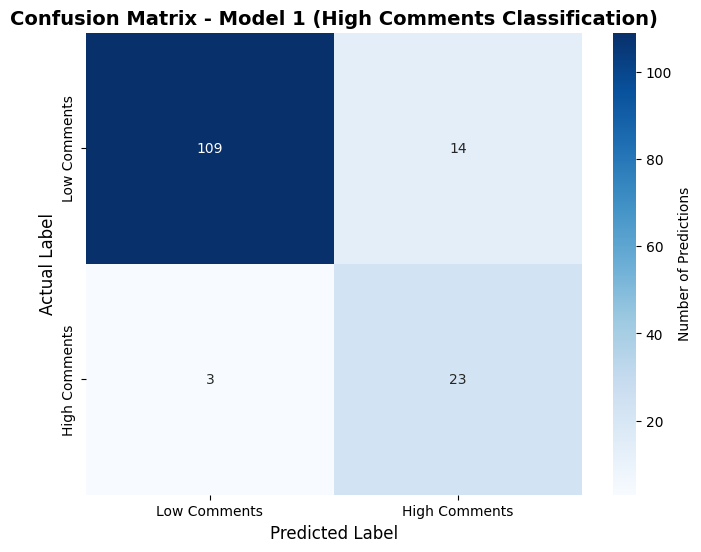

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low Comments', 'High Comments'],
            yticklabels=['Low Comments', 'High Comments'],
            cbar_kws={'label': 'Number of Predictions'})

plt.title('Confusion Matrix - Model 1 (High Comments Classification)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.show()

##### Cross-Validation

Cross-validation scores: [0.73154362 0.77852349 0.93959732 0.96621622 0.91891892]

Summary Statistics:
Average CV accuracy: 0.8670
Standard deviation: 0.0938
95% Confidence interval: 0.8670 (+/- 0.1876)


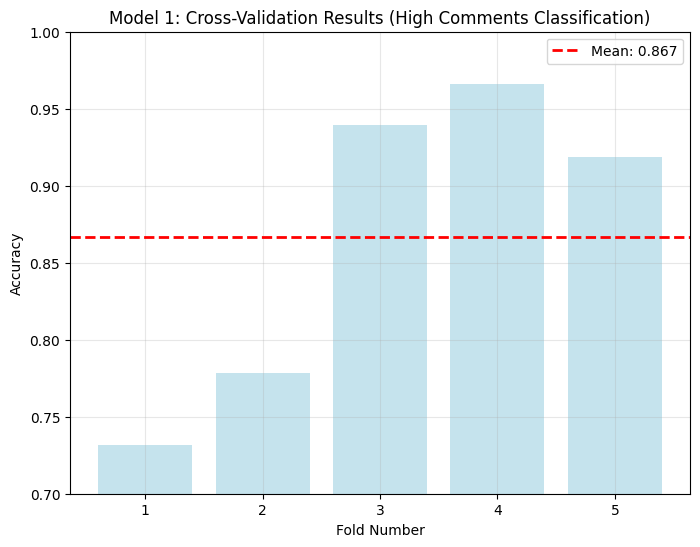

In [23]:
from sklearn.model_selection import cross_val_score
cv_scores1 = cross_val_score(model1, X1, y1, cv=5)

print(f"Cross-validation scores: {cv_scores1}")

print(f"\nSummary Statistics:")
print(f"Average CV accuracy: {cv_scores1.mean():.4f}")
print(f"Standard deviation: {cv_scores1.std():.4f}")
print(f"95% Confidence interval: {cv_scores1.mean():.4f} (+/- {cv_scores1.std() * 2:.4f})")

plt.figure(figsize=(8, 6))
plt.bar(range(1, 6), cv_scores1, color='lightblue', alpha=0.7)
plt.axhline(y=cv_scores1.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {cv_scores1.mean():.3f}')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('Model 1: Cross-Validation Results (High Comments Classification)')
plt.ylim(0.7, 1.0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 5.2 Model 2: High Engagement vs Normal Engagement (Logistic Regression)

In [24]:
X2 = data[['comment_count', 'title_length', 'age']]
y2 = data['high_points']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

model2 = LogisticRegression(class_weight='balanced', random_state=42)
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)

accuracy2 = accuracy_score(y_test2, y_pred2)

In [25]:
print("MODEL2:")
print(f"Accuracy: {accuracy2:.3f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test2, y_pred2))

# Calculate additional metrics
cm2 = confusion_matrix(y_test2, y_pred2)
tn, fp, fn, tp = cm2.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

print(f"\nAdditional Metrics:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")
print(f"Specificity (True Negative Rate): {specificity:.3f}")
print(f"Sensitivity (True Positive Rate): {sensitivity:.3f}")

MODEL2:
Accuracy: 0.872

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       122
           1       0.62      0.78      0.69        27

    accuracy                           0.87       149
   macro avg       0.78      0.84      0.80       149
weighted avg       0.89      0.87      0.88       149


Additional Metrics:
True Negatives: 109
False Positives: 13
False Negatives: 6
True Positives: 21
Specificity (True Negative Rate): 0.893
Sensitivity (True Positive Rate): 0.778


##### Decision Boundary

3-Feature Model Coefficients:
Comment Count: 0.0292
Title Length: -0.0210
Age: 0.0007
Intercept: -0.8487


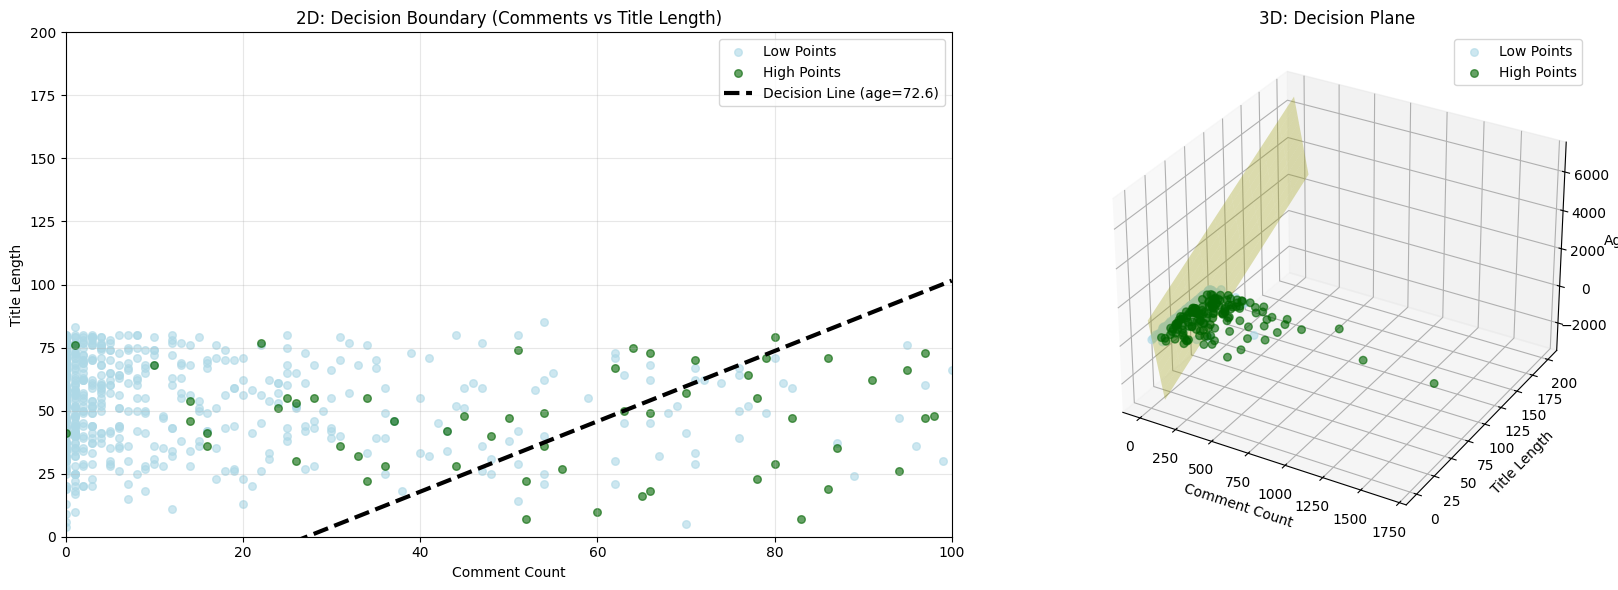

In [26]:
coef2 = model2.coef_[0]
intercept2 = model2.intercept_[0]

print(f"3-Feature Model Coefficients:")
print(f"Comment Count: {coef2[0]:.4f}")
print(f"Title Length: {coef2[1]:.4f}")
print(f"Age: {coef2[2]:.4f}")
print(f"Intercept: {intercept2:.4f}")

plt.figure(figsize=(18, 6))


low_points_posts = data[data['high_points'] == 0]
high_points_posts = data[data['high_points'] == 1]

# 2D Plot (Comment Count vs Title Length)
plt.subplot(1, 2, 1)
plt.scatter(low_points_posts['comment_count'], low_points_posts['title_length'], 
           color='lightblue', alpha=0.6, label='Low Points', s=30)
plt.scatter(high_points_posts['comment_count'], high_points_posts['title_length'], 
           color='darkgreen', alpha=0.6, label='High Points', s=30)

# Decision line for average age
age_avg = data['age'].mean()
x_line = np.linspace(0, 100, 100)  # comment_count range
y_line = -(coef2[0] * x_line + coef2[2] * age_avg + intercept2) / coef2[1]

# Plot the line
plt.plot(x_line, y_line, 'k--', linewidth=3, label=f'Decision Line (age={age_avg:.1f})')

plt.xlabel('Comment Count')
plt.ylabel('Title Length')
plt.title('2D: Decision Boundary (Comments vs Title Length)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 100)
plt.ylim(0, 200)

# 3D Plot
from mpl_toolkits.mplot3d import Axes3D
ax = plt.subplot(1, 2, 2, projection='3d')

ax.scatter(low_points_posts['comment_count'], low_points_posts['title_length'], 
           low_points_posts['age'], c='lightblue', alpha=0.6, s=30, label='Low Points')
ax.scatter(high_points_posts['comment_count'], high_points_posts['title_length'], 
           high_points_posts['age'], c='darkgreen', alpha=0.6, s=30, label='High Points')

# 3D Decision plane
xx, yy = np.meshgrid(np.linspace(0, 100, 10), np.linspace(0, 200, 10))
zz = -(coef2[0] * xx + coef2[1] * yy + intercept2) / coef2[2]
ax.plot_surface(xx, yy, zz, alpha=0.3, color='yellow')

ax.set_xlabel('Comment Count')
ax.set_ylabel('Title Length')
ax.set_zlabel('Age')
ax.set_title('3D: Decision Plane')
ax.legend()

plt.tight_layout()
plt.show()

##### Confusion Matrix

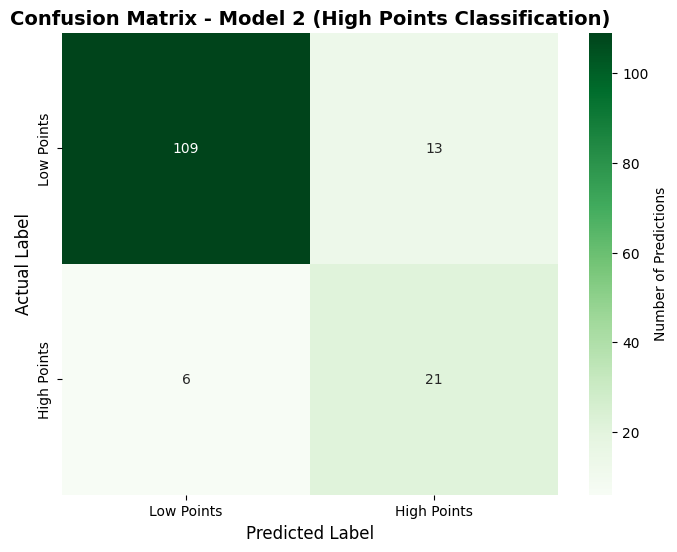

In [27]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Low Points', 'High Points'],
            yticklabels=['Low Points', 'High Points'],
            cbar_kws={'label': 'Number of Predictions'})

plt.title('Confusion Matrix - Model 2 (High Points Classification)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.show()

##### Cross-Validation

Cross-validation scores: [0.76510067 0.8590604  0.90604027 0.93918919 0.93243243]

Summary Statistics:
Average CV accuracy: 0.8804
Standard deviation: 0.0641
95% Confidence interval: 0.8804 (+/- 0.1283)


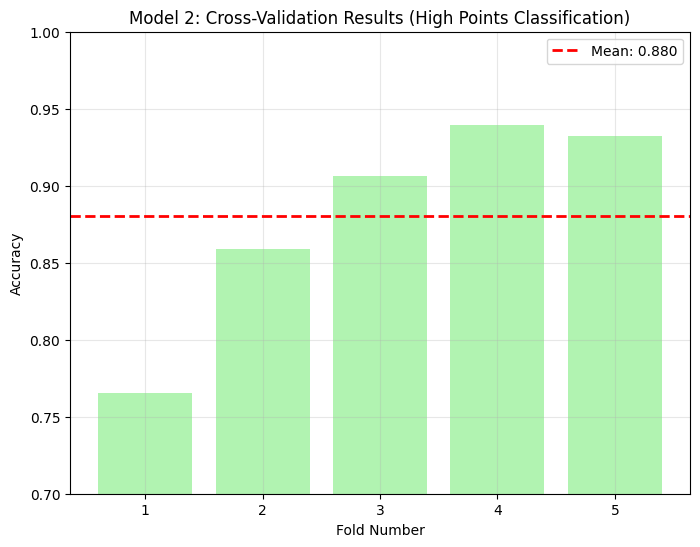

In [28]:
cv_scores2 = cross_val_score(model2, X2, y2, cv=5)

print(f"Cross-validation scores: {cv_scores2}")

print(f"\nSummary Statistics:")
print(f"Average CV accuracy: {cv_scores2.mean():.4f}")
print(f"Standard deviation: {cv_scores2.std():.4f}")
print(f"95% Confidence interval: {cv_scores2.mean():.4f} (+/- {cv_scores2.std() * 2:.4f})")

plt.figure(figsize=(8, 6))
plt.bar(range(1, 6), cv_scores2, color='lightgreen', alpha=0.7)
plt.axhline(y=cv_scores2.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {cv_scores2.mean():.3f}')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('Model 2: Cross-Validation Results (High Points Classification)')
plt.ylim(0.7, 1.0)  # Adjusted for realistic range
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 5.3 Model 3: High Points Prediction (Random Forest)

In [29]:
from sklearn.ensemble import RandomForestClassifier

X3 = data[['comment_count', 'title_length', 'age']]
y3 = data['high_points']

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.2, random_state=42)

model3 = RandomForestClassifier(class_weight='balanced')
model3.fit(X_train3, y_train3)
y_pred3 = model3.predict(X_test3)

accuracy3 = accuracy_score(y_test3, y_pred3)

In [30]:
print("MODEL 3:")
print(f"Accuracy: {accuracy3:.3f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test3, y_pred3))

# Calculate additional metrics
cm3 = confusion_matrix(y_test3, y_pred3)
tn, fp, fn, tp = cm3.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

print(f"\nAdditional Metrics:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")
print(f"Specificity (True Negative Rate): {specificity:.3f}")
print(f"Sensitivity (True Positive Rate): {sensitivity:.3f}")

MODEL 3:
Accuracy: 0.859

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       122
           1       0.65      0.48      0.55        27

    accuracy                           0.86       149
   macro avg       0.77      0.71      0.73       149
weighted avg       0.85      0.86      0.85       149


Additional Metrics:
True Negatives: 115
False Positives: 7
False Negatives: 14
True Positives: 13
Specificity (True Negative Rate): 0.943
Sensitivity (True Positive Rate): 0.481


##### Decision Analysis

Random Forest Feature Importance:
Comment Count: 0.6897
Title Length: 0.1831
Age: 0.1272


c:\Users\MSI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


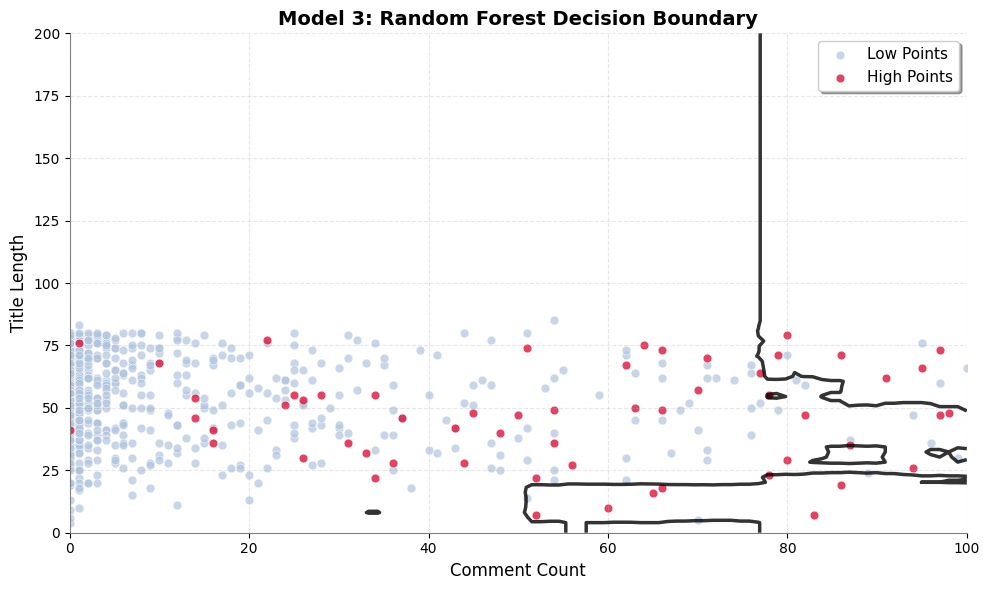

In [31]:
feature_names_3 = ['Comment Count', 'Title Length', 'Age']
importances = model3.feature_importances_

print(f"Random Forest Feature Importance:")
print(f"Comment Count: {importances[0]:.4f}")
print(f"Title Length: {importances[1]:.4f}")
print(f"Age: {importances[2]:.4f}")

plt.figure(figsize=(10, 6))

low_points_posts = data[data['high_points'] == 0]
high_points_posts = data[data['high_points'] == 1]

# Plot data points
plt.scatter(low_points_posts['comment_count'], low_points_posts['title_length'], 
           color='lightsteelblue', alpha=0.7, label='Low Points', s=40, edgecolors='white', linewidth=0.5)
plt.scatter(high_points_posts['comment_count'], high_points_posts['title_length'], 
           color='crimson', alpha=0.8, label='High Points', s=40, edgecolors='white', linewidth=0.5)

# Create decision boundary
x_min, x_max = 0, 100
y_min, y_max = 0, 200
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Use average age for 2D visualization
avg_age = data['age'].mean()
mesh_points = np.c_[xx.ravel(), yy.ravel(), np.full(xx.ravel().shape, avg_age)]

# Get probability predictions
Z = model3.predict_proba(mesh_points)[:, 1]
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='-', linewidths=2.5, alpha=0.8)

plt.xlabel('Comment Count', fontsize=12)
plt.ylabel('Title Length', fontsize=12)
plt.title('Model 3: Random Forest Decision Boundary', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, 100)
plt.ylim(0, 200)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('gray')
plt.gca().spines['bottom'].set_color('gray')

plt.tight_layout()
plt.show()

##### Confusion Matrix

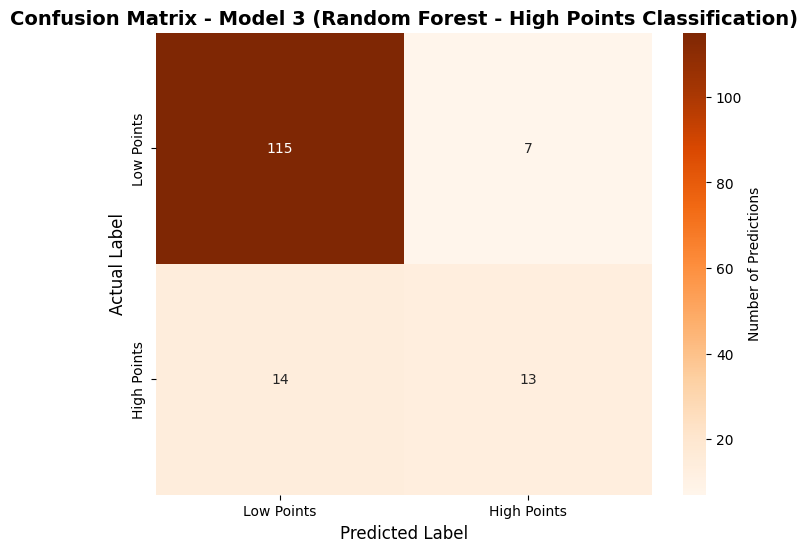

In [32]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Low Points', 'High Points'],
            yticklabels=['Low Points', 'High Points'],
            cbar_kws={'label': 'Number of Predictions'})

plt.title('Confusion Matrix - Model 3 (Random Forest - High Points Classification)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.show()

##### Cross-Validation

Cross-validation scores: [0.75167785 0.85234899 0.87919463 0.89864865 0.89864865]

Summary Statistics:
Average CV accuracy: 0.8561
Standard deviation: 0.0549
95% Confidence interval: 0.8561 (+/- 0.1098)


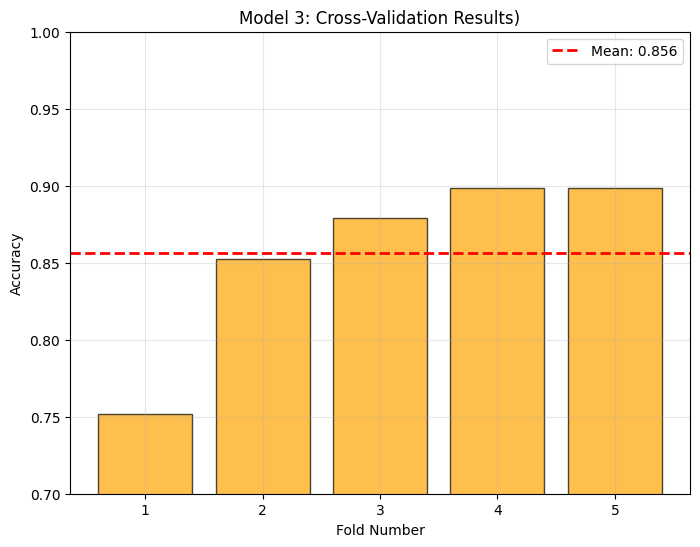

In [33]:
cv_scores3 = cross_val_score(model3, X3, y3, cv=5)

print(f"Cross-validation scores: {cv_scores3}")

print(f"\nSummary Statistics:")
print(f"Average CV accuracy: {cv_scores3.mean():.4f}")
print(f"Standard deviation: {cv_scores3.std():.4f}")
print(f"95% Confidence interval: {cv_scores3.mean():.4f} (+/- {cv_scores3.std() * 2:.4f})")

plt.figure(figsize=(8, 6))
plt.bar(range(1, 6), cv_scores3, color='orange', alpha=0.7, edgecolor='black')
plt.axhline(y=cv_scores3.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {cv_scores3.mean():.3f}')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('Model 3: Cross-Validation Results)')
plt.ylim(0.7, 1.0)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()